---
title: Parts-Based Decomposition via Disjoint Basis Learning
description: A niche novel algorithm for finding the basis vectors for a dataset where the basis don't overlap on the same dimension
categories: [Math, Optimization]
date: 'May 29, 2026'
bibliography: [dictionary-learning.bib, nmf.bib, Pattern_Recognition_and_Machine_Learning.bibtex, gaussian-scaled-mixture.bib,olivetti-faces.bib, ica.bib]
---

Lately I've been working on neural network interpretability, looking inside a network to understand why it behaves the way it does. A core challenge is decomposing internal representations into meaningful parts. The choice of *how* you decompose matters quite a bit — different assumptions lead to very different results.

I've been wondering about having an optimisation which discourages overlap between atoms on the same dimension. This can be useful in datasets where we expect that the generation process had no overlap.  


**Non-negative Matrix Factorization (NMF)** [@Lee1999] and **Independent Component Analysis (ICA)** [@HYVARINEN2000411] work quite well for this, if the actual data has this property.  
The algorithm I describe here explicitly penalizes overlap. Using this with ICA is useful.   
If the basis vectors found using the algorithm here are similar to the ones found by ICA consistently, we can generally assume that the data generation process has some sort of overlapping.  

::: {.callout-warning}
The parts-based representation here has no spatial notion, dimensions that are close to each other do not cluster.
:::

::: {.callout-important}
I had started out work on this algorithm without really looking closely at ICA.  
For most of the data I've tested on, ICA gives better and faster results.  
As such, the algorithm presented here does not provide anything novel or useful it seems.   
I've written about it simply because it was very intuitive to arrive at using a probabilistic generation model for gradient descent.  

Anyone who wants to see how probabilistic models work out on a non-standard example, this might be interesting.  
:::

# Problem statement and notation


We are given a dataset with $N$ samples, each with $C$ dimensions, represented as a matrix $X \in \mathbb{R}^{N \times C}$, where each row is a sample.

We approximate $X$ as:
$$\hat{X} = SW$$

where:

- $S \in \mathbb{R}^{N \times R}$ is the coefficient matrix, with row $i$ denoted $\vec{s_{r_i}}$
- $W \in \mathbb{R}^{R \times C}$ is the basis matrix, where:
  - Row $i$ is denoted $\vec{w_{r_i}}$
  - Column $j$ is denoted $\vec{w_{c_j}}$
  - The scalar at row $i$, column $j$ is $w_{r_i c_j}$

::: {.callout-note}
We will be working with both rows and columns in the $W$ matrix. This is why I'm moving away from the standard notation for the extra expressivity.   
:::

Additionally, we constrain $W$ such that for any column $j$, at most one row of $W$ has a non-zero entry. Equivalently, the rows of $W$ have **disjoint support**, meaning no two basis vectors are active on the same dimension.

# Probabilistic model

Consider the random variables:

- $W$: the collection of basis vectors (matrix with $K$ components × $D$ dimensions)
- $\vec{s}$: a vector of coefficients for a single input example
- $\vec{x}$: a vector of a single input

We want to find $p(W\vec{s}|\vec{x})$. From Bayesian rule:

$$p(W\vec{s}|\vec{x}) = \frac{p(\vec{x}|W\vec{s})P(W|\vec{s})p(\vec{s})}{p(\vec{x})}$$

$p(\vec{x})$ is a marginalizing constant, and can be ignored.  

$$p(W\vec{s}|\vec{x}) \propto p(\vec{x}|W\vec{s})P(W|\vec{s})p(\vec{s})$$

We will now make the following modeling choices, which are very similar to linear regression:

- $p(\vec{x}|W\vec{s}) = \mathcal{N}(\vec{x}|W\vec{s}, \sigma_{\epsilon}^2)$, modeling $\vec{x}$ as $W\vec{s} + \epsilon$ with Gaussian noise
- $p(W|\vec{s}) = p(W)$, assuming $W$ and $\vec{s}$ are sampled independently
- $p(\vec{s}) = \mathcal{N}(\vec{s}|0, \sigma_s^2)$, a Gaussian prior on $\vec{s}$ to regularize optimization; without it, gradient descent overfits $\vec{s}$ to the reconstruction

$$p(W\vec{s}|\vec{x}) \propto \mathcal{N}(\vec{x}|W\vec{s}, \sigma_{\epsilon}^2) \mathcal{N}(\vec{s}|0, \sigma_s^2) P(W)$$


The key modeling choice is the prior $P(W)$, which we constrain to enforce disjoint support.

## Constraining $p(W)$ for disjoint support

We denote the element at row $i$, column $j$ of $W$ as $w_{r_i c_j}$, where $r_i$ is the $i$-th component ($i \in [0, K-1]$) and $c_j$ is the $j$-th dimension ($j \in [0, D-1]$).


Writing $p(W)$ in terms of its components:  

$$p(W) = p(w_{r_0 c_0})p(w_{r_0 c_1}|w_{r_0 c_0})p(w_{r_0 c_2}|w_{r_0 c_0},w_{r_0 c_1}) \cdots p(w_{r_{K-1} c_{D-1}}|w_{r_0 c_0}, w_{r_0 c_1}, \ldots, w_{r_{K-1} c_{D-2}})$$

Now remember that the goal is to ensure no two basis vectors share a non-zero value in the same column. Within each column, at most one entry may be non-zero, we don't really care about what other columns are doing. We can therefore assume that columns are independent.  
The equation then, can be written in terms of the columns of the matrix. Since they are independent, the product rule simplifies to:


$$p(W) = \prod_{j=0}^{D-1} p(\vec{w}_{c_j}) $$

where $\vec{w}_{c_j} = [w_{r_0 c_j}, \ldots, w_{r_{K-1} c_j}]^T$ denotes the vector of all component weights for dimension $c_j$. 

### Constraining Each Column

The constraint has been delegated to $p(\vec{w}_{c_j})$. Expanding by the product rule:

$$p(\vec{w}_{c_j}) = p(w_{r_0 c_j})p(w_{r_1 c_j}|w_{r_0 c_j})\cdots p(w_{r_{K-1} c_j}|w_{r_0 c_j}, \ldots, w_{r_{K-2} c_j})$$

A simple way to do this would be:

- sample from $\mathcal{N}(0, \sigma_{w_{c_j}}^2)$ when no non-zero value has appeared in the column yet
- sample from $\text{Laplace}(0, b)$ otherwise, maximising the probability of fetching $0$
  - $Laplace$ is known to give sparseness to a data structure. The famous L1 regularisation can be derived using Laplace distribution as a prior.  

This formulation is a mixture of distributions. However, this leads to a combinatorial explosion — the number of cases doubles at each step, producing a tree of $2^K$ leaves.

Instead, we use Gaussian scale mixtures [@10.1214/06-BA117A]. The key intuition is that a Gaussian distribution with a very low $\sigma$ has a very high probability of sampling a $0$. It can act as a proxy of Laplace. We can now constrain the variance.  

$$p(w_{r_i c_j}|w_{r_0 c_j}, \ldots, w_{r_{i-1} c_j}) = \mathcal{N}(0, \sigma_{w_{r_i c_j}}^2)\, p(\sigma_{w_{r_i c_j}}^2|w_{r_0 c_j}, \ldots, w_{r_{i-1} c_j})$$


So the variance is now dependent on the previous weights in the column. We would to further simplify this by simply writing the variance as a determinstic function of the previous weights and initial variance $\sigma_0$.  
To simplify, we treat $\sigma_{w_{r_i c_j}}^2$ as a deterministic function of the previous entries rather than a random variable. This is achieved by setting:
$$\sigma_{w_{r_i c_j}}^2 = f(w_{r_0 c_j}, \ldots, w_{r_{i-1} c_j})$$

This is however, not valid under the rules of working with probability directly.  
There is a trick though:  
You can assume that $p(\sigma)$ is a [Dirac Delta function](https://en.wikipedia.org/wiki/Dirac_delta_function), centered at $f(w_{r_0 c_j}, \ldots, w_{r_{i-1} c_j})$.  Dirac Delta function has infinite probability at its center, and its integration is $1$, so it can act as a probability distribution.  


$$p(\sigma_{w_{r_i c_j}}^2|w_{r_0 c_j}, \ldots, w_{r_{i-1} c_j}) = \delta\!\left(\sigma_{w_{r_i c_j}}^2 - f(w_{r_0 c_j}, \ldots, w_{r_{i-1} c_j})\right)$$

which collapses the distribution to a point mass at , giving:

$$p(w_{r_i c_j}|w_{r_0 c_j}, \ldots, w_{r_{i-1} c_j}) = \mathcal{N}(0, \sigma_{w_{r_i c_j}}^2) \quad \text{where} \quad \sigma_{w_{r_i c_j}}^2 = f(w_{r_0 c_j}, \ldots, w_{r_{i-1} c_j})$$

::: {.callout-caution}
Laplace distributions produce exact zeros under optimization. The Gaussian approximation used here instead concentrates mass near zero,

:::

### Finding $f$

In the base case, $p(w_{r_0 c_j}) = \mathcal{N}(0, \sigma_0^2)$. For $i > 0$, we require $\sigma_{w_{r_i c_j}}^2$ to collapse toward zero when any preceding entry in the column is non-zero. We measure this via $x = \sum_{k=0}^{i-1} w_{r_k c_j}^2$ and choose $f$ such that $\sigma^2$ decreases rapidly as $x$ increases. We consider two candidates:

- Laplace kernel: $\sigma_{w_{r_i c_j}}^2 = \sigma_0^2 e^{\frac{-|x|}{b}}$
- Lorentzian: $\sigma_{w_{r_i c_j}}^2 = \frac{\sigma_0^2}{1 + \alpha x^2}$

These are plotted for various hyperparameter choices below. 


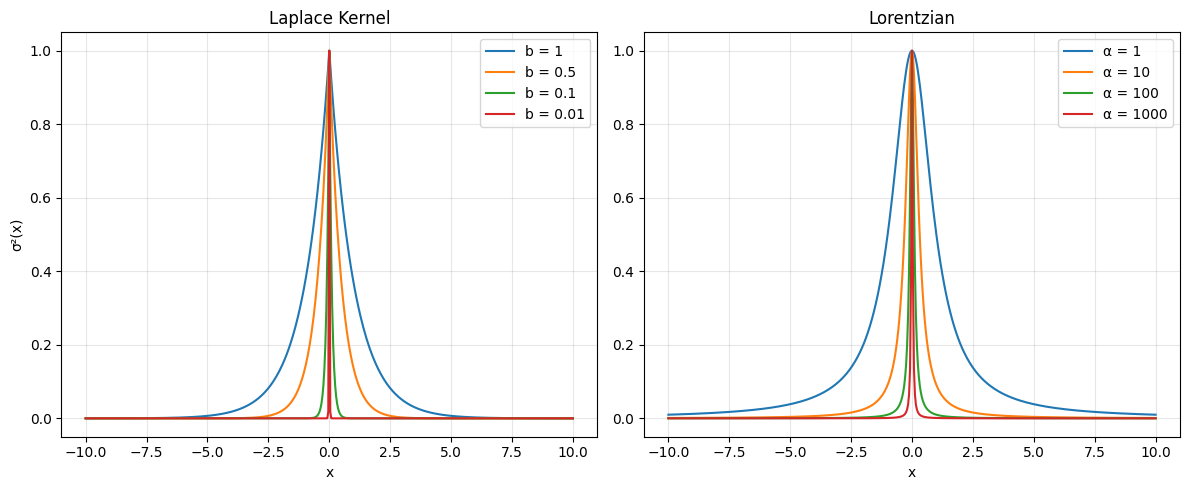

In [ ]:
# | code-fold: true
import matplotlib.pyplot as plt
import numpy as np

x = np.concatenate([np.linspace(-10, 0, 250), np.linspace(0, 10, 250)])

sigma0_sq = 1.0

b_values = [1, 0.5, 0.1, 0.01]
alpha_values = [1, 10, 100, 1000]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Laplace kernel
ax = axes[0]
for b in b_values:
    y = sigma0_sq * np.exp(-np.abs(x) / b)
    ax.plot(x, y, label=f"b = {b}")
ax.set_title("Laplace Kernel")
ax.set_xlabel("x")
ax.set_ylabel("σ²(x)")
ax.legend()
ax.grid(True, alpha=0.3)

# Lorentzian
ax = axes[1]
for alpha in alpha_values:
    y = sigma0_sq / (1 + alpha * x**2)
    ax.plot(x, y, label=f"α = {alpha}")
ax.set_title("Lorentzian")
ax.set_xlabel("x")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("kernels.png", dpi=150)
plt.show()

I proceeded with the Lorentzian because it fits naturally into the Gaussian exponent. Using the Laplace kernel is awkward, it puts an exponent in the main exponent.   


$$
\begin{align*}
\sigma_{w_{r_i c_j}}^2 &= \frac{\sigma_{0}^2}{1 + \alpha\sum_{k=0}^{i-1}w_{r_k c_j}^2} \\
&= \frac{\sigma_{0}^2}{\phi(w, i-1, c_j)} \quad \text{where} \quad \phi(w, i, c_j)=1 + \alpha\sum_{k=0}^{i}w_{r_k c_j}^2 \\[14pt]
p(w_{r_i c_j}|w_{r_0 c_j}, w_{r_1 c_j}, \ldots, w_{r_{i-1} c_j}) &= \mathcal{N}(0, \sigma_{w_{r_i c_j}}^2) \\
&= \frac{1}{\sqrt{2\pi\sigma_{w_{r_i c_j}}^2}}\exp\left(\frac{-w_{r_i c_j}^2}{2\sigma_{w_{r_i c_j}}^2}\right) \\
&= \frac{\sqrt{\phi(w,i-1,c_j)}}{\sqrt{2\pi}\sigma_0}\exp\left(\frac{-w_{r_i c_j}^2\phi(w,i-1,c_j)}{2\sigma_0^2}\right) \\[14pt]
\end{align*}
$$

Substituting in the main expression:
$$
\begin{align*}
p(\vec{w}_{c_j}) &= p(w_{r_0 c_j})p(w_{r_1 c_j}|w_{r_0 c_j})p(w_{r_2 c_j}|w_{r_0 c_j}, w_{r_1 c_j})\cdots p(w_{r_{K-1} c_j}|w_{r_0 c_j}, \ldots, w_{r_{K-2} c_j}) \\[6pt]
&= \prod_{i=0}^{K-1} \frac{\sqrt{\phi(w,i-1,c_j)}}{\sqrt{2\pi}\sigma_0}\exp\left(\frac{-w_{r_i c_j}^2\phi(w,i-1,c_j)}{2\sigma_0^2}\right) \\
p(W) &= \prod_{j=0}^{D-1} p(\vec{w}_{c_j}) \\
&= \prod_{j=0}^{D-1} \prod_{i=0}^{K-1} \frac{\sqrt{\phi(w,i-1,c_j)}}{\sqrt{2\pi}\sigma_0}\exp\left(\frac{-w_{r_i c_j}^2\phi(w,i-1,c_j)}{2\sigma_0^2}\right)
\end{align*}
$$

::: {.callout-important}
$p(\vec{w}_{c_j})$ is asymmetric in the row ordering: earlier rows are favored to take non-zero values. In practice this did not appear to affect the learned representations for many of my tests — averaging the loss over all cyclic permutations of the row ordering yields identical results.   
In case you feel that it does, its easy to simply calculate the loss by starting from every row in the matrix, and then average the computed values. This makes the loss symmetric.  
:::

## The full distribution

$$
\begin{gather*}
p(W\vec{s}|\vec{x}) \propto \mathcal{N}(\vec{x}|W\vec{s}, \sigma_{\epsilon}^2) \mathcal{N}(\vec{s}|0, \sigma_s^2) \prod_{j=0}^{D-1} \prod_{i=0}^{K-1}\mathcal{N}(w_{r_i c_j}|\sigma_{w_{r_i c_j}}^2) \\
\sigma_{w_{r_i c_j}}^2 = \frac{\sigma_0^2}{\phi(w, i-1, c_j)} \quad \text{where} \quad \phi(w, i, c_j)=1 + \alpha\sum_{k=0}^{i}w_{r_k c_j}^2
\end{gather*}
$$

# Loss function

We take the negative log of the probability distribution to get the loss function.  

$$
\begin{align*}
-\ln(p(W)) &= -\ln\left(\prod_{j=0}^{D-1} \prod_{i=0}^{K-1}\mathcal{N}(w_{r_i c_j}|\sigma_{w_{r_i c_j}}^2)\right)  \\
&= \frac{1}{2} \sum_{j=0}^{D-1} \sum_{i=0}^{K-1} \left[\ln(2\pi) + \ln(\sigma_{w_{r_i c_j}}^2) + \frac{w_{r_i c_j}^2}{\sigma_{w_{r_i c_j}}^2} \right] \\
&= \frac{1}{2} \sum_{j=0}^{D-1} \sum_{i=0}^{K-1} \left[ \ln(2\pi) + \ln(\sigma_0^2) - \ln(\phi(w,i-1,c_j)) + \frac{w_{r_i c_j}^2\phi(w,i-1,c_j)}{\sigma_0^2} \right] \\
\end{align*}
$$

Note that $\ln(p(W))$ is written in the form of each number $w_{r_i c_j}$, we therefore also write $p(\vec{s})$ and $p(\vec{x}|W,\vec{s})$ in the form of each number in the vector. Not doing this can result in handling the dimensions incorrectly later.  

$$
\begin{align*}
-\ln (p(\vec{x}|W,\vec{s})) &= \frac{1}{2} \sum_{j=0}^{D-1} \left[\ln(2\pi) + \ln(\sigma_{\epsilon}^2) + \frac{(x_j-W_{c_j}s_j)^2}{\sigma_{\epsilon}^2} \right] \\
-\ln (p(\vec{s})) &= \frac{1}{2} \sum_{j=0}^{D-1} \left[ \ln(2\pi) + \ln(\sigma_s^2) + \frac{s_j^2}{\sigma_s^2} \right] \\
\end{align*}
$$

Removing the terms containing only constants (including the hyperparameters $\sigma_s, \sigma_0, \sigma_{\epsilon}$)

$$
\begin{align*}
-\ln(p(W\vec{s}|\vec{x})) &\propto -\ln(p(\vec{x}|W\vec{s})) - \ln(P(W|\vec{s})) - \ln(p(\vec{s})) \\
&\propto \sum_{j=0}^{D-1} \left[
    \frac{(\vec{x}-W\vec{s})^2}{\sigma_{\epsilon}^2}
    + \frac{s^2}{\sigma_s^2}
    + \sum_{i=0}^{K-1}\left(-\ln(\phi(w,i-1,c_j)) + \frac{w_{r_i c_j}^2\phi(w,i-1,c_j)}{\sigma_0^2} \right)
    \right] \\
\end{align*} 
$$


We can take out the outer sum for simplicity.  

$$
-\ln(p(W\vec{s}|\vec{x})) 
\propto 
    \frac{(\vec{x}-W\vec{s})^2}{\sigma_{\epsilon}^2}
    + \frac{s^2}{\sigma_s^2}
    + \sum_{i=0}^{K-1}\left(-\ln(\phi(w,i-1,c_j)) + \frac{w_{r_i c_j}^2\phi(w,i-1,c_j)}{\sigma_0^2} \right)
$$

This will translate to code now as:
- For each sample, we take the mean of individual MSE components, mean of the individual $s_{ij}$ components, and the mean of the disjoint loss across columns (the disjoint loss is summed inside the column).  


Some simple substitutions, useful later. Most of the loss components are pretty standard.  
$$
\begin{align*}
\text{MSE}(X - WS) &=\frac{(\vec{x}-W\vec{s})^2}{\sigma_{\epsilon}^2}  \\
\text{L2}(S) &= \frac{s^2}{\sigma_s^2} \\
\text{DisjointLoss}(W) &= \sum_{i=0}^{K-1}\left[-\ln(\phi(w,i-1,c_j)) + \frac{w_{r_i c_j}^2\phi(w,i-1,c_j)}{\sigma_0^2} \right] \\
\end{align*}
$$

## Hyperparameters

We have 4 hyperparameters: $\sigma_{\epsilon}, \sigma_0, \sigma_s, \alpha$.  
These hyperparamaters are quite sensitive, and it is useful to understand what they mean, giving us good starting points.  

$\sigma_0$ and $\alpha$ are very tightly connected, we'll create a simple formula for an $\alpha$ value which works generally.  

### $\sigma_0$ and $\alpha$

$\sigma_0$ is the standard deviation of the Gaussian from which $w_{rc}$ is sampled when no preceding entry in the column is non-zero. $\alpha$ controls how rapidly this standard deviation shrinks for subsequent entries:

$$\sigma_{w_{rc}}^2 = \frac{\sigma_0^2}{1 + \alpha\sum_{i=0}^{r-1}w_{ic}^2} = \frac{\sigma_0^2}{1 + \alpha x^2}$$

The plots below show this function for $\sigma_0=1$ and $\sigma_0=0.1$ across the same set of $\alpha$ values. For smaller $\sigma_0$, the same $\alpha$ produces a slower collapse. We need a narrower curve. It seems $\alpha$ and $\sigma_0$ are not independent.   



In [20]:
# | code-fold: true
# | code-summary: code helper plotting functions

## helper plotting functions
import numpy as np
import matplotlib.pyplot as plt

def _single_plot(ax, sigma_0, alphas, x_limit=None):
    if x_limit is not None:
        lo, hi = x_limit
        x = np.concatenate([np.linspace(lo, 0, 250), np.linspace(0, hi, 251)[1:]])

    for alpha in alphas:
        sigma = np.sqrt(sigma_0**2 / (1 + (alpha * (x**2))))
        ax.plot(x, sigma, label=f"alpha={alpha}")

    ax.set_title(f"sigma_0^2={sigma_0**2:.2e}")
    ax.set_xlabel("x")
    ax.set_ylabel("sigma(x)")
    if x_limit is not None:
        ax.set_xlim(*x_limit)
        ax.set_ylim(0, x_limit[1])
    ax.legend()
    ax.grid(True, alpha=0.3)


def plot_lorentz_for_sigma_0_and_alpha_compare(
    examples
):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle("plot of sigma_w_rc^2 wrt sigma_0^2 and alpha")
    _single_plot(axes[0], examples[0]["sigma_0"], examples[0]["alphas"], examples[0]["x_limits"])
    _single_plot(axes[1], examples[1]["sigma_0"], examples[1]["alphas"], examples[1]["x_limits"])
    plt.tight_layout()
    plt.show()

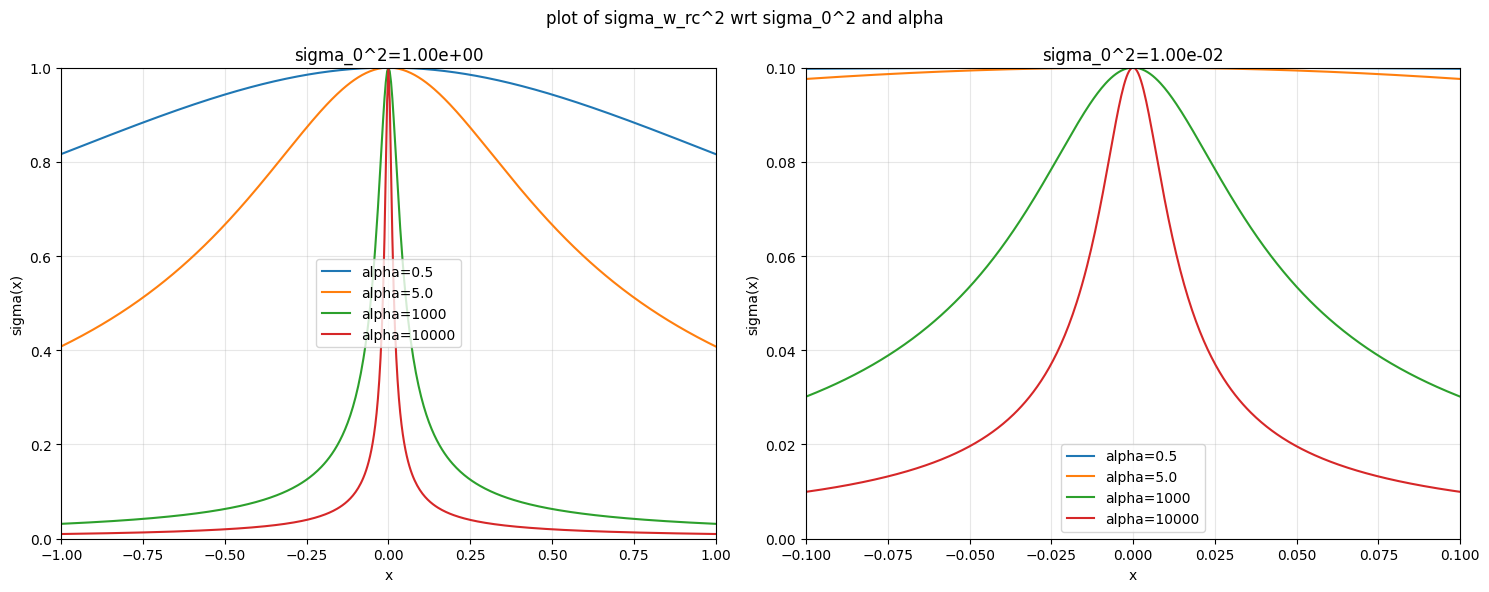

In [18]:
# | code-fold: true

examples = [
    {
        "sigma_0": 1.0,
        "alphas": [0.5, 5.0, 1000, 10_000],
        "x_limits": [-1.0, 1.0],
    },
    {
        "sigma_0": 0.1,
        "alphas": [0.5, 5.0, 1000, 10_000],
        "x_limits": [-0.1, 0.1],
    },
]

plot_lorentz_for_sigma_0_and_alpha_compare(examples)

The plots below use $\frac{\alpha}{\sigma_0^2}$ as the effective hyperparameter across $\sigma_0 \in [1, 10^{-1}, 10^{-3}, 10^{-4}]$; the curves are identical across all values, confirming this scaling.

::: {.callout-important}
$\alpha$ should be set inversely proportional to $\sigma_0^2$. Since $w_{rc} \sim \mathcal{N}(0, \sigma_0^2)$, we have $x^2 \in [0, 3\sigma_0^2]$ with high probability, making $\alpha = \frac{c}{\sigma_0^2}$ a natural choice. Empirically, $c \in [1000, 10000]$ works well. This keeps $\alpha x^2$ stable across different $\sigma_0$ values.
:::

<!-- We need a thinner curve for $\sigma_0=0.01$.  

::: {.callout-important}
$\alpha$ is not a simple scalar. It should be inversely proportional to $x^2$. Since $x$ itself is sampled from $\mathcal{N}(0, \sigma_0^2)$, $x^2$ is in the range $[-3\sigma_0^2, 3\sigma_0^2]$, giving us using $\alpha = \frac{constant}{\sigma_0^2}$ a good heuristic.  
A useful empirical value is the range $constant \in [1000, 10,000]$.  
What this basically does is keep $\alpha x^2$ predictable and stable across different $\sigma_0$ values.  
:::

The next plots use $\frac{\alpha}{\sigma_0^2}$ as the effective $\alpha$ value. Using $\sigma_0 \in [1, 1e-1, 1e-3, 1e-4]$.   
Notice that with this small change, we get identical plots for all $\sigma_0$ values.   -->

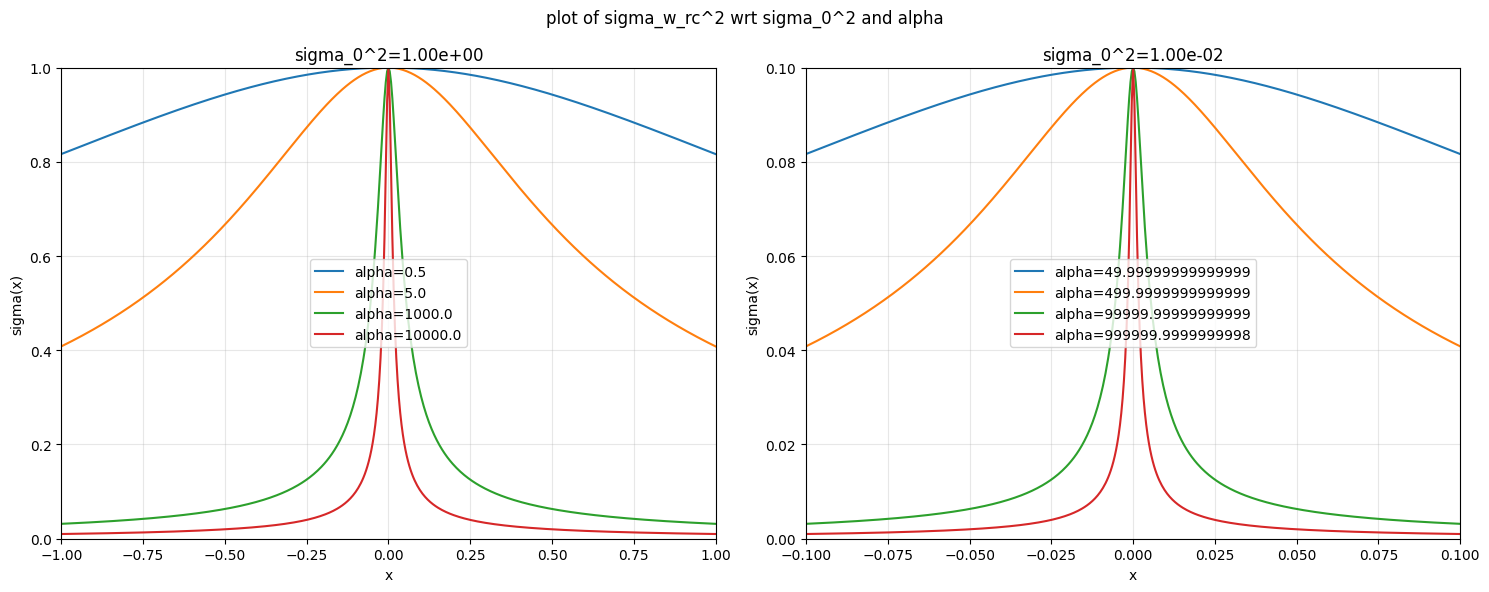

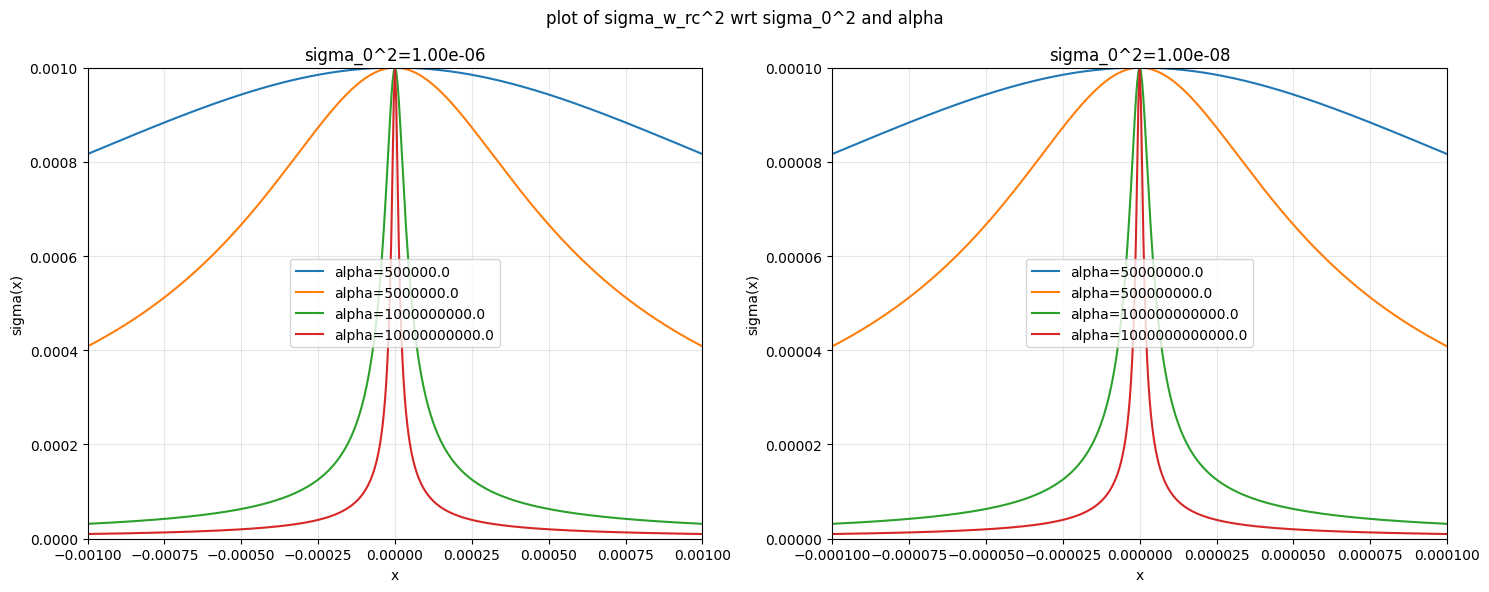

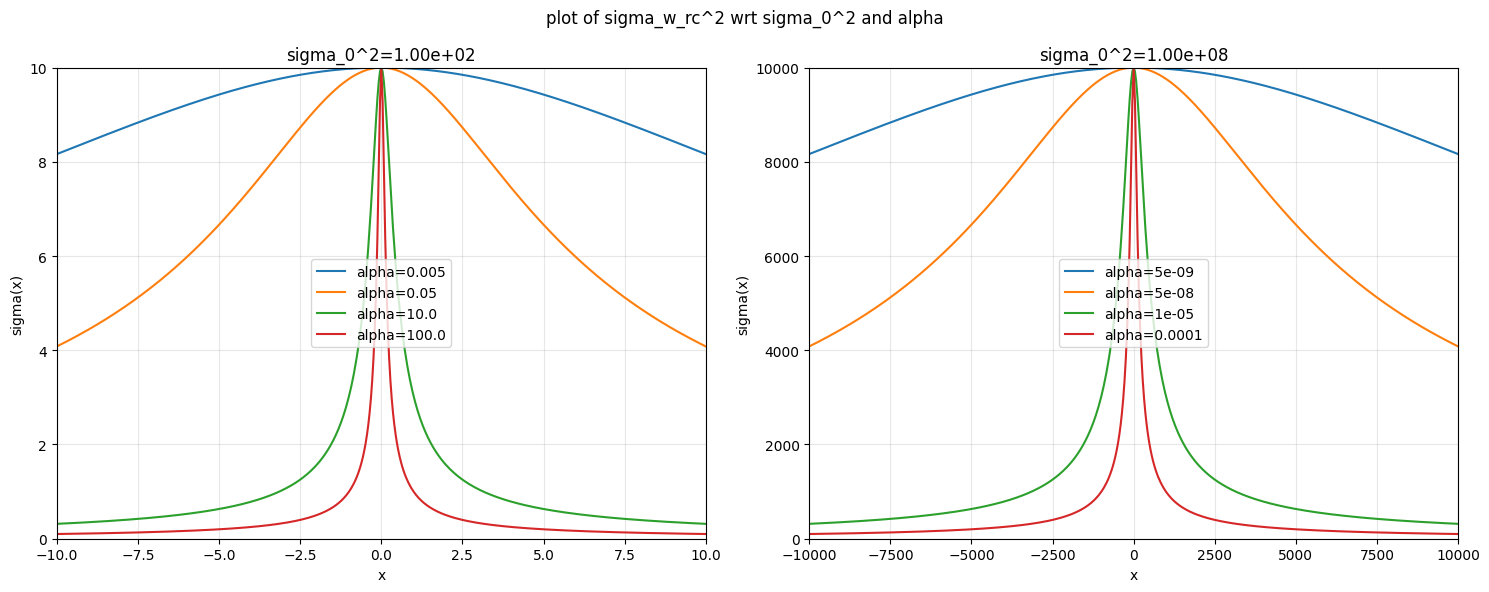

In [22]:
# | code-fold: true
def _d(a, s):
    return a / (s*s)

examples = [
    {
        "sigma_0": 1.0,
        "alphas": [_d(a, 1.0) for a in [0.5 , 5.0, 1000, 10_000]],
        "x_limits": [-1.0, 1.0],
    },
    {
        "sigma_0": 0.1,
        "alphas": [_d(a, 0.1) for a in [0.5 , 5.0, 1000, 10_000]],
        "x_limits": [-0.1, 0.1],
    },
]

plot_lorentz_for_sigma_0_and_alpha_compare(examples)


examples = [
    {
        "sigma_0": 1e-3,
        "alphas": [_d(a, 1e-3) for a in [0.5 , 5.0, 1000, 10_000]],
        "x_limits": [-1e-3, 1e-3],
    },
    {
        "sigma_0": 1e-4,
        "alphas": [_d(a, 1e-4) for a in [0.5 , 5.0, 1000, 10_000]],
        "x_limits": [-1e-4, 1e-4],
    },
]

plot_lorentz_for_sigma_0_and_alpha_compare(examples)


examples = [
    {
        "sigma_0": 10.0,
        "alphas": [_d(a, 10.0) for a in [0.5 , 5.0, 1000, 10_000]],
        "x_limits": [-10.0, 10.0],
    },
    {
        "sigma_0": 10000.,
        "alphas": [_d(a, 10000.) for a in [0.5 , 5.0, 1000, 10_000]],
        "x_limits": [-10000., 10000.],
    },
]

plot_lorentz_for_sigma_0_and_alpha_compare(examples)

### ${\sigma_{\epsilon}}$

The model assumes the error is distributed under $\mathcal{N}(0, \sigma_{\epsilon})$. We want a good estimate of this.  
The easiest way is to simply minimise **only** reconstruction loss ($MSE$). The code uses a very basic autoencoder (covered in the next section). We simply train a baseline autoencoder to do this. And simply use: 
$$\sigma_{\epsilon} = stddev((X - Reconstruction_{baseline}))$$

You would want $\sigma_0$ now to be bigger than $\sigma_{\epsilon}$, but still be reasonably small.  

### $\sigma_s$ and $\sigma_0$

To maintain smooth training, $\sigma_s$ and $\sigma_0$ need to have the following property:
$$K \sigma_s^2 \sigma_w^2 = \sigma_x^2$$

Empirically on synthetic tests, I've found that keeping both of the hyperparameters equal gives the best results.  
$$ \sigma_s = \sigma_w = \frac{\sigma_x}{\sqrt{K}}$$

This makes intuitive sense, we want to regularise both components so that the network does not cheat and use one component to create the input.  

### summary

$$
\begin{align*}
\sigma_{\epsilon} &= stddev((X - Reconstruction_{baseline})) \\
\sigma_s &= \sigma_w = \frac{\sigma_x}{\sqrt{K}} \\
\alpha &= \frac{5000}{\sigma_0^2} \\
\end{align*}
$$

Generally, we also assign the initial weights of the network using values derived from these $\sigma_s$ and $\sigma_0$, it ends up giving better convergence.  

# An autoencoder with our loss function

The architecture follows a standard autoencoder design, similar to a Sparse Autoencoder (SAE) — a single-layer encoder-decoder network trained to reconstruct its input through a bottleneck.


Given input $\vec{x}$, the encoder projects it to a latent representation $\vec{s} = \vec{x}E$, and the decoder reconstructs it as $\hat{\vec{x}} = \vec{s}W$. The only departure from a vanilla SAE is the loss function.


::: {.callout-note}
A more classical solution like how dictionary learning is implemented in `sklearn` with coordinate descent might work too, I've not tested it out.  
:::

The main model code is quite simple. Along with loss function definitions. The `weights_loss_cycled` function finds the loss of the weights starting from all rows and averages it. The `weights_loss` function does the same thing, but only using the first row as starting point. Both are vectorized.  

In [ ]:
import time
from dataclasses import dataclass
import numpy as np
import torch
from torch import nn
from torch import optim
from typing import Any

class Autoencoder(nn.Module):
    def __init__(self, input_dim, n_components):
        super().__init__()
        self.encoder = nn.Linear(input_dim, n_components, bias=True)
        self.decoder = nn.Linear(n_components, input_dim, bias=False)

    def forward(self, x):
        codes = self.encoder(x)
        recon = self.decoder(codes)
        return recon, codes


def recon_loss(x, recons, sigma_eps):
    """Reconstruction loss. MSE"""
    return gauss_loss(x, recons) / (sigma_eps * sigma_eps)


def codes_loss(codes, sigma_s):
    """L2 loss on encoder"""
    return gauss_loss(codes, 0) / (sigma_s * sigma_s)


def gauss_loss(x, mean):
    loss = (x - mean) ** 2
    # return torch.sum(loss, 1).mean()
    return loss.mean()

def weights_loss_cycled(alpha, sigma_0, W):
    """Vectorized weight loss averaged over all starting positions."""
    C, K = W.shape
    W_sq = W ** 2  # (C, K)

    # Build all K cyclic shifts: (C, K, K)
    # shifts[c, s, :] = W_sq[c, :] rolled by -s
    idx = (torch.arange(K).unsqueeze(0) - torch.arange(K).unsqueeze(1)) % K  # (K, K)
    W_sq_shifted = W_sq[:, idx]  # (C, K, K)

    cumsum = torch.cumsum(W_sq_shifted, dim=2)             # (C, K, K)
    phi = alpha * torch.roll(cumsum, 1, dims=2) + 1        # (C, K, K)
    phi[:, :, 0] = 1

    comp1 = (W_sq_shifted * phi / (sigma_0 * sigma_0)).sum(dim=2)  # (C, K)
    comp2 = (-torch.log(phi)).sum(dim=2)                            # (C, K)

    # average over shifts (dim=1), then over channels (dim=0)
    return comp1.mean(), comp2.mean()

def weights_loss(alpha, sigma_0, W):
    """Vectorized version the Weight loss"""
    W_sq = W**2  # (C, K)
    cumsum = torch.cumsum(W_sq, dim=1)  # (C, K), cumsum[c,k] = sum W[c,0..k]^2
    phi = alpha * torch.roll(cumsum, 1, dims=1) + 1  # (C, K)
    phi[:, 0] = 1  # k=0: phi_weight(W, c, -1, alpha) = alpha*0 + 1
    comp1 = (W_sq * phi) / (sigma_0 * sigma_0)
    comp2 = -torch.log(phi)
    return comp1.sum(dim=1).mean(), comp2.sum(dim=1).mean()



## Training code

Interesting aspects of the code:

- `train` is the main function. It first calls `train_baseline` which gives us the MSE without any regularisation. This is used as $\sigma_{\epsilon} = \sqrt{MSE_{baseline}}$.  
- The two initialisations below lead to faster convergence
    - The decoder weights are initialised with $\frac{\sigma_0}{\sqrt{K}}$.  
    - The encoder outputs $S = XE$, where $E$ are the encoder weights. This implies the relationship $D\sigma_x^2\sigma_{enc}^2 = \sigma_s^2$, where $D$ is the number of dimensions of $X$. We therefore initialise $\sigma_{enc} = \frac{\sigma_x}{\sqrt{D}\sigma_x}$. 
- The $\ln$ works in the opposite direction from the main component of the disjoint loss, it's value increases as weights become lower. 
    - In practice, this term has very low gradients and scale. And the algorithm anyways only works if we have good reconstruction. Sometimes, it makes sense to just remove the term (removing this term brings sparser weights, which is a win most of the times).  
    - By default, we don't use this term.  
- Initialising the decoder using SVD
    - SVD outputs a set of orthogonal vectors with maximum variance. Using this leads to faster convergence many times.  

In [ ]:
import time
from dataclasses import dataclass
import numpy as np
import torch
from torch import nn
from torch import optim
from typing import Any

@dataclass
class SingleRun:
    model: Any
    codes: np.ndarray
    components: np.ndarray
    recon: np.ndarray
    loss: float
    hyperparameters: dict



def get_scaled_hyperparamters(
    sigma_x,
    input_dim,
    n_components,
    sigma_eps,
    w_to_eps_ratio=5,
    alpha_constant=10_000.0,
    sigma_s_rel_to_0="equal",
):
    """
    sigma_x      : std of your data
    eps_ratio    : sigma_x / sigma_eps (default 100)
    w_to_eps_ratio: sigma_0 / sigma_eps (default 5)
    alpha_constant: the c in alpha = c / sigma_0^2
    """
    if sigma_s_rel_to_0 == "equal":
        sigma_0 = sigma_s = sigma_x / np.sqrt(n_components)
    elif sigma_s_rel_to_0 == "less":
        sigma_s = sigma_eps * w_to_eps_ratio
        sigma_0 = sigma_x / sigma_s 
    else:
        sigma_0 = sigma_eps * w_to_eps_ratio
        sigma_s = sigma_x / sigma_0

    sigma_enc = sigma_s / (
        np.sqrt(input_dim) * sigma_x
    )  # from D*sigma_enc^2*sigma_x^2 = sigma_s^2
    alpha = alpha_constant / (sigma_0**2)

    return dict(
        sigma_eps=sigma_eps,
        sigma_0=sigma_0,
        sigma_s=sigma_s,
        sigma_enc=sigma_enc,
        alpha=alpha,
    )


def init_encoder_using_normal(model, sigma_enc):
    # encoder weights
    nn.init.normal_(model.encoder.weight, mean=0.0, std=sigma_enc)
    nn.init.zeros_(model.encoder.bias)


def init_model_parameters_using_normal(model, scaled_hyperparameters, n_components):
    p = scaled_hyperparameters
    sigma_0, sigma_enc = p["sigma_0"], p["sigma_enc"]

    # decoder = W, init with sigma_0
    nn.init.normal_(model.decoder.weight, mean=0.0, std=sigma_0/np.sqrt(n_components))
    # nn.init.normal_(model.decoder.weight, mean=0.0, std=sigma_0)
    init_encoder_using_normal(model, sigma_enc)


def init_model_parameters_using_svd(model, X, n_components, scaled_hyperparameters, device):
    p = scaled_hyperparameters

    # svd
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    w = torch.tensor(Vt[:n_components].T, dtype=torch.float32).to(device)
    # scale
    w = (w / w.std()) * (p["sigma_0"]/np.sqrt(n_components))
    model.decoder.weight.data = w

    # encoder weights
    init_encoder_using_normal(model, p["sigma_enc"])


@dataclass
class StandardInitStrategy:
    def __repr__(self):
        return "'StandardInitStrategy'"

@dataclass
class NoInitStrategy:
    def __repr__(self):
        return "'NoInitStrategy'"

@dataclass
class SvdInitStrategy:
    def __repr__(self):
        return "'SvdInitStrategy'"

@dataclass
class WarmupInitStrategy:
    warmup_epochs: int

    def __repr__(self):
        return f"'WarmupInitStrategy({self.warmup_epochs})'"

InitStrategy = SvdInitStrategy | WarmupInitStrategy | StandardInitStrategy|NoInitStrategy

def get_hyperparameters_and_init(
    model, X, n_components, input_dim, sigma_eps, init_strat:InitStrategy=NoInitStrategy(), sigma_s_rel_to_0="equal", device="cpu"
):
    sigma_x = X.std()
    scaled_hyperparameters = get_scaled_hyperparamters(
        sigma_x,
        input_dim,
        n_components,
        sigma_eps=sigma_eps,
        w_to_eps_ratio=5,
        alpha_constant=5000,
        sigma_s_rel_to_0=sigma_s_rel_to_0,
    )
    if isinstance(init_strat, SvdInitStrategy):
        init_model_parameters_using_svd(model, X, n_components, scaled_hyperparameters, device)
    elif isinstance(init_strat, StandardInitStrategy):
        init_model_parameters_using_normal(model, scaled_hyperparameters, n_components)
    return scaled_hyperparameters

def train(
    X,
    n_components,
    lr=1e-3,
    epochs=2000,
    batch_size=2048,
    verbose=True,
    init_strategy: InitStrategy=StandardInitStrategy(),
    initialised_model=None,
    use_ln_term=False,
    sigma_s_rel_to_0="equal",
    device="mps",
    baseline_epochs=1000,
    sigma_eps_override=None,
) -> SingleRun:
    """
    X: numpy array (n_samples, input_dim)
    n_components: number of dictionary atoms
    alpha: lorentzian sigma shrinker parameter
    """
    print("using hyperparameters")
    print("\tinit_strategy", init_strategy)
    print("\tuse_ln", use_ln_term)
    print("\tsigma_s_rel_to_0", sigma_s_rel_to_0)
    
    X_t = torch.tensor(X, dtype=torch.float32)
    n_samples, input_dim = X_t.shape
    X_t = X_t.to(device)

    baseline_run = train_baseline(X, n_components, lr, baseline_epochs, batch_size, verbose)
    sigma_eps = np.sqrt(baseline_run.loss)
    tol = X.std() / 10_000
    if sigma_eps < tol:
        print(f"WARM: sigma_eps={sigma_eps} is less than tolerance={tol}, this can have undesired behavior")
        sigma_eps = tol
    if sigma_eps_override is not None:
        sigma_eps = sigma_eps_override

    print("baseline MSE", baseline_run.loss)

    if initialised_model is None:
        model = Autoencoder(input_dim, n_components)
    else:
        model = initialised_model

    model = model.to(device)


    scaled_hyperparameters = get_hyperparameters_and_init(
        model, X, n_components, input_dim, sigma_eps, init_strategy, sigma_s_rel_to_0, device
    )

    p = scaled_hyperparameters
    sigma_eps, sigma_0, sigma_s, _, alpha = (
        p["sigma_eps"],
        p["sigma_0"],
        p["sigma_s"],
        p["sigma_enc"],
        p["alpha"],
    )
    print("using hyperparameters:", p)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    if isinstance(init_strategy, WarmupInitStrategy):
        warmup_with_l2(
            X_t,
            model,
            init_strategy.warmup_epochs,
            optimizer,
            batch_size,
            sigma_eps,
            sigma_s,
            sigma_0,
            verbose=verbose,
            device=device,
        )


    last_print_time = time.time()

    for epoch in range(epochs):
        # shuffle
        idx = torch.randperm(n_samples, device=device)
        permuted_X_t = X_t[idx]

        for i in range(0, n_samples, batch_size):
            batch = permuted_X_t[i : i + batch_size]
            recon, codes = model(batch)

            _recon_loss = recon_loss(batch, recon, sigma_eps)
            _codes_loss = codes_loss(codes, sigma_s)
            comp1, comp2 = weights_loss_cycled(alpha, sigma_0, model.decoder.weight)

            if use_ln_term:
                weight_loss = comp1 + comp2
            else:
                weight_loss = comp1

            loss = _recon_loss + weight_loss + _codes_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if verbose and epoch % 200 == 0:
            print(
                f"epoch {epoch:4d} | recon_loss {_recon_loss:.4f} weight_loss {weight_loss:.4f} codes_loss {_codes_loss:.4f} duration={time.time() - last_print_time}"
            )
            last_print_time = time.time()

    with torch.no_grad():
        recon, codes = model(X_t)

    return SingleRun(
        model.to("cpu"),
        codes.to("cpu").numpy(),
        model.decoder.weight.T.detach().to("cpu").numpy(),
        recon.to("cpu").numpy(),
        ((X_t - recon) ** 2).to("cpu").mean(),
        scaled_hyperparameters,
    )


def warmup_with_l2(
    X_t, model, epochs, optimizer, batch_size, sigma_eps, sigma_s, sigma_0, verbose=True, device="mps"
):
    print("starting warmup: epochs =", epochs)
    n_samples, input_dim = X_t.shape
    for epoch in range(epochs):
        idx = torch.randperm(n_samples, device=device)
        permuted_X_t = X_t[idx]
        for i in range(0, n_samples, batch_size):
            batch = permuted_X_t[i : i + batch_size]
            recon, codes = model(batch)
            _recon_loss = recon_loss(batch, recon, sigma_eps)
            _codes_loss = codes_loss(codes, sigma_s)
            _weights_loss = gauss_loss(model.decoder.weight, 0) / (sigma_0 * sigma_0)

            loss = _recon_loss + _codes_loss + _weights_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if verbose and epoch % 200 == 0:
            print(f"warmup: epoch {epoch:4d} | recon_loss {_recon_loss:.4f}")




def train_baseline(
    X,
    n_components,
    lr=1e-3,
    epochs=2000,
    batch_size=256,
    verbose=True,
):
    """Train the autoencoder with just reconstruction loss, to find an arbitrary linear model which fits the data

    The main training code requires sigma_eps
    the standard deviation of expected gaussian noise
    when the curve is fitted using Y=WX
    We can generally do a simple sweep of hyperparams
    or use simple heuristics
    If the data is linearly "fittable",
    then we get a good starting point
    using this function.
    """
    print(f"training baseline model, epochs={epochs}")
    X_t = torch.tensor(X, dtype=torch.float32)
    n_samples, input_dim = X_t.shape

    model = Autoencoder(input_dim, n_components)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        idx = torch.randperm(n_samples)
        permuted_X_t = X_t[idx]
        for i in range(0, n_samples, batch_size):
            batch = permuted_X_t[i : i + batch_size]
            recon, codes = model(batch)
            _recon_loss = recon_loss(batch, recon, 1)
            loss = _recon_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if verbose and epoch % 200 == 0:
            print(f"finetune epoch {epoch:4d} | recon_loss {_recon_loss:.4f}")

    with torch.no_grad():
        recon, codes = model(X_t)

    return SingleRun(
        model,
        codes.numpy(),
        model.decoder.weight.T.detach().numpy(),
        recon.numpy(),
        ((X_t - recon) ** 2).mean().item(),
        {},
    )

## Testing on synthetic data

We generate synthetic data as follows:

- For `n_components`, create a set of basis vectors which don't overlap. This would be $W$
- Randomly generate $S$ (the matrix with $\vec{s}$ rows)
- Generate the data using $SW$ with some overall gaussian noise.  


This is a very simple dataset. We will notice that ICA also gives very good results in this dataset.  

## plotting utilities

In [ ]:
import numpy as np
import math
from itertools import batched
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.colors as mcolors

# the std one has too less contrast
# std_dark_colors = ["red", "black", "green"]
colors_dark_v2 = ["#FF3131", "#333333", "#39FF14"]
rd_bk_gn = mcolors.LinearSegmentedColormap.from_list("RdBkGn", colors_dark_v2)
rd_bk_gn.set_bad("yellow")

# Crimson -> Gainsboro (Very light grey) -> Dark Green
colors_white = ["#B22222", "#D3D3D3", "#00A550"]
rd_wht_gn = mcolors.LinearSegmentedColormap.from_list("RdBkGn", colors_white)
rd_wht_gn.set_bad("yellow")

def show_single_channel_red_green_black(
    images, figsize=None, ncols=2, axis="on", viztype="global", mode="dark", suptitle="", ax_titles=None
):
    if len(images) == 1:
        ncols = 1
    fig, axs, v_limit = _plot_single_channel_red_green_black(
        images, figsize, ncols, axis, viztype, mode, suptitle, ax_titles
    )
    return axs


def _plot_single_channel_red_green_black(
    images, figsize=None, ncols=2, axis="on", viztype="global", mode="dark", suptitle="", ax_titles=None
):
    if not images:
        return None, None, None

    if images[0].dtype == np.uint8:
        images = [img.astype(np.float32) for img in images]

    all_min = min(img.min() for img in images)
    all_max = max(img.max() for img in images)
    v_limit = max(abs(all_min), abs(all_max))

    images = list(images)
    rows = math.ceil(len(images) / ncols)
    if figsize is None:
        figsize = (5 * rows, 5 * rows)
    if figsize is not None and isinstance(figsize, int):
        figsize = (figsize, figsize)

    fig, axs = plt.subplots(rows, ncols, figsize=figsize)
    fig.suptitle(suptitle)
    if len(images) > 1:
        axs = axs.flatten()
    else:
        axs = [axs]

    for i, img in enumerate(images):
        params = {}
        if viztype == "gray":
            params["cmap"] = "gray"
        else:
            cmap = rd_bk_gn if mode == "dark" else rd_wht_gn
            params["cmap"] = cmap
            if viztype == "global":
                params["vmin"], params["vmax"] = -v_limit, v_limit
            elif viztype == "local":
                params["vmin"], params["vmax"] = get_local_image_limits(img)
            else:
                raise Exception(f"invalid viztype {viztype}")

        axs[i].imshow(img, **params)
        axs[i].axis(axis)
    
    if ax_titles is not None:
        for i in range(len(axs)):
            if i < len(ax_titles):
                axs[i].set_title(ax_titles[i])

    plt.tight_layout()
    return fig, axs, v_limit

S = show_single_channel_red_green_black


def show_closest_component_of_W_for_each_component(
    components, W_true, image_shape, figsize=(5, 2), comps_per_row=3, mode="light"
):
    """
    Given two arrays of numpy vectors of same shapes
    for every component in `components`, this function shows the array in `W_true`
    which has the maximum cosine similarity with the component
    """
    sims = np.abs(cosine_similarity(components, W_true))
    pairs = []
    for i in range(len(components)):
        j = np.argmax(sims[i])
        pairs.append((i, j, sims[i][j]))
    for batch in batched(pairs, comps_per_row):
        ax_titles, comps, scores = [], [], []

        for i, j, score in batch:
            comps.extend(
                [components[i].reshape(image_shape), W_true[j].reshape(image_shape)]
            )
            ax_titles.extend([f"component\n{score:.5f}", "ground_truth"])
            # scores.append(score)
        S(
            comps,
            figsize,
            2 * comps_per_row,
            mode=mode,
            # suptitle=f"similarity score={score}",
            ax_titles=ax_titles,
            viztype="local",
        )
        plt.show()


def get_local_image_limits(img):
    # return (img.min(), img.max())
    mx, mn = img.max(), img.min()
    mx = max(abs(mx), abs(mn))
    lim = (-mx, mx)
    return lim


## create dataset and test

In [64]:
def make_dim_partition(patch_dim, n_components, seed=42):
    rng = np.random.RandomState(seed)
    perm = rng.permutation(patch_dim)
    return [list(perm[i::n_components]) for i in range(n_components)]

def generate_synthetic_patches(
    patch_dim=72,
    n_components=10,
    k=3,
    n_samples=1000,
    noise_std=0.01,
    seed=42,
    sigma_x=1,
):
    rng = np.random.RandomState(seed)

    dim_partition = make_dim_partition(patch_dim, n_components, seed)

    # ground truth atoms, nonzero only on owned dims
    W_true = np.zeros((n_components, patch_dim))
    for i, dims in enumerate(dim_partition):
        W_true[i, dims] = rng.randn(len(dims))
    W_true /= np.linalg.norm(W_true, axis=1, keepdims=True)

    # each sample uses at most k atoms
    codes_true = np.zeros((n_samples, n_components))
    for i in range(n_samples):
        k_i = rng.randint(1, k + 1)  # active atoms: 1..k
        idx = rng.choice(n_components, k_i, replace=False)
        codes_true[i, idx] = rng.randn(k_i)

    X = codes_true @ W_true

    scale = sigma_x / X.std()
    X *= scale
    W_true *= scale  # keeps codes_true @ W_true ≈ X
    X += rng.randn(*X.shape) * noise_std

    return X, W_true, codes_true, dim_partition

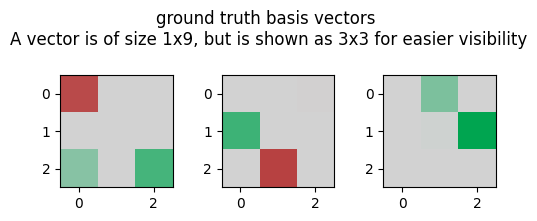

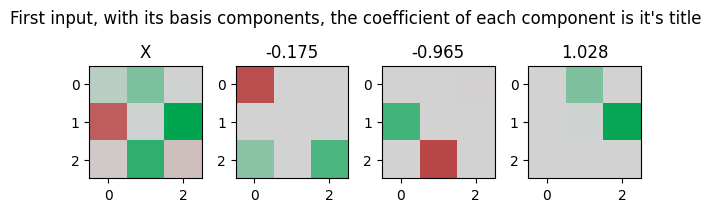

In [75]:
#| code-fold: true
#| code-summary: Code for Synthetic data generation script
N_COMPS = 3
N_DIM = 9
X, W_true, codes_true, dim_partition = generate_synthetic_patches(
    N_DIM, N_COMPS, seed=10, n_samples=2000
)
MODE = "light"


ws_to_show = [w.reshape(3, 3) for w in W_true]
S(
    ws_to_show,
    (5, 2),
    ncols=3,
    mode=MODE,
    suptitle="ground truth basis vectors \nA vector is of size 1x9, but is shown as 3x3 for easier visibility",
)
plt.show()

S(
    [X[0].reshape(3, 3)] + ws_to_show,
    (6, 2),
    4,
    suptitle="First input, with its basis components, the coefficient of each component is it's title",
    mode=MODE,
    ax_titles=[
        "X",
        f"{codes_true[0][0]:.3f}",
        f"{codes_true[0][1]:.3f}",
        f"{codes_true[0][2]:.3f}",
    ],
)
plt.show()

In [76]:
#| code-fold: true
#| code-summary: Code for model training script

run = train(X, 3, epochs=2000, use_ln_term=False)

using hyperparameters
	init_strategy 'StandardInitStrategy'
	use_ln False
	sigma_s_rel_to_0 equal
training baseline model, epochs=1000
finetune epoch    0 | recon_loss 1.0474
finetune epoch  200 | recon_loss 0.6275
finetune epoch  400 | recon_loss 0.1105
finetune epoch  600 | recon_loss 0.0070
finetune epoch  800 | recon_loss 0.0003
baseline MSE 9.025086183100939e-05
using hyperparameters: {'sigma_eps': np.float64(0.009500045359418521), 'sigma_0': np.float64(0.5773633860009654), 'sigma_s': np.float64(0.5773633860009654), 'sigma_enc': np.float64(0.19245008972987526), 'alpha': np.float64(14999.318453715941)}
epoch    0 | recon_loss 13456.0625 weight_loss 2313.9363 codes_loss 1.0077 duration=1.750365972518921
epoch  200 | recon_loss 7450.8633 weight_loss 852.2167 codes_loss 1.4723 duration=0.8518407344818115
epoch  400 | recon_loss 3468.4819 weight_loss 664.5606 codes_loss 3.8649 duration=0.8978240489959717
epoch  600 | recon_loss 795.3248 weight_loss 644.8210 codes_loss 6.3395 duration=0

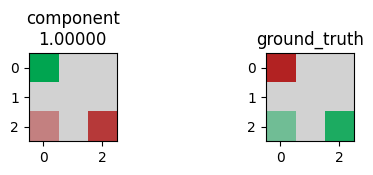

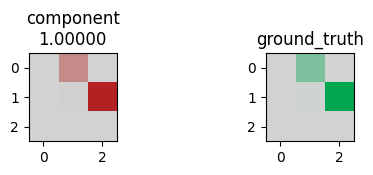

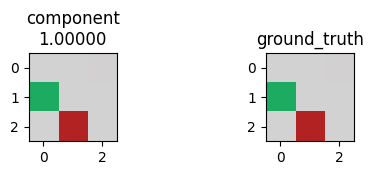

In [77]:
show_closest_component_of_W_for_each_component(run.components, W_true, (3,3), (5,2), 1)

ICA gives the same results (it seems its really the superior method)

In [79]:
from sklearn.decomposition import FastICA
ica_estimator = FastICA(
    n_components=3, max_iter=10_000, whiten="arbitrary-variance", tol=15e-5
)
ica_estimator.fit(X)

,"n_components n_components: int, default=NoneNumber of components to use. If None is passed, all are used.",3
,"algorithm algorithm: {'parallel', 'deflation'}, default='parallel'Specify which algorithm to use for FastICA.",'parallel'
,"whiten whiten: str or bool, default='unit-variance'Specify the whitening strategy to use.- If 'arbitrary-variance', a whitening with variance arbitrary is used.- If 'unit-variance', the whitening matrix is rescaled to ensure that each recovered source has unit variance.- If False, the data is already considered to be whitened, and no whitening is performed... versionchanged:: 1.3 The default value of `whiten` changed to 'unit-variance' in 1.3.",'arbitrary-variance'
,"fun fun: {'logcosh', 'exp', 'cube'} or callable, default='logcosh'The functional form of the G function used in theapproximation to neg-entropy. Could be either 'logcosh', 'exp',or 'cube'.You can also provide your own function. It should return a tuplecontaining the value of the function, and of its derivative, in thepoint. The derivative should be averaged along its last dimension.Example:: def my_g(x): return x ** 3, (3 * x ** 2).mean(axis=-1)",'logcosh'
,"fun_args fun_args: dict, default=NoneArguments to send to the functional form.If empty or None and if fun='logcosh', fun_args will take value{'alpha' : 1.0}.",None
,"max_iter max_iter: int, default=200Maximum number of iterations during fit.",10000
,"tol tol: float, default=1e-4A positive scalar giving the tolerance at which theun-mixing matrix is considered to have converged.",0.00015
,"w_init w_init: array-like of shape (n_components, n_components), default=NoneInitial un-mixing array. If `w_init=None`, then an array of valuesdrawn from a normal distribution is used.",None
,"whiten_solver whiten_solver: {""eigh"", ""svd""}, default=""svd""The solver to use for whitening.- ""svd"" is more stable numerically if the problem is degenerate, and often faster when `n_samples <= n_features`.- ""eigh"" is generally more memory efficient when `n_samples >= n_features`, and can be faster when `n_samples >= 50 * n_features`... versionadded:: 1.2",'svd'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed to initialize ``w_init`` when not specified, with anormal distribution. Pass an int, for reproducible resultsacross multiple function calls.See :term:`Glossary `.",None


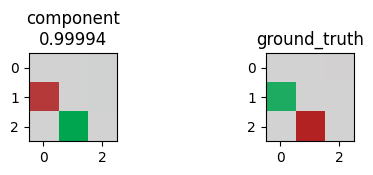

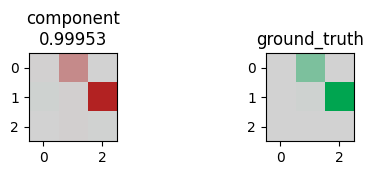

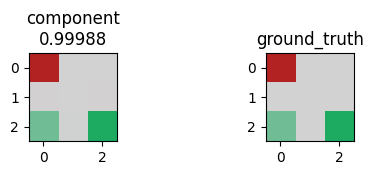

In [81]:
show_closest_component_of_W_for_each_component(ica_estimator.mixing_.T, W_true, (3,3), (5,2), 1)

# Concluding

When I had stumbled upon this function, I was quite excited about it. I've tested it on data with multiple noise types, and ICA seems to perform at least as good as this method.   

ICA can give slightly noisy data, a sparser representation might be more interpretable, where this method might find some use.  

A very simple usecase of this method however, is to check whether there is some disjoint support in your underlying data. If it produces good reconstruction (low MSE), you can assume that there is some disjoint support in your components.  
Obviously, if you keep increasing your components, the MSE will get better. It is useful to check the elbow of the loss curve, where it starts to plateau, to see if there are any atoms which explain your data with disjoint support.   